In [30]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.query import (
    get_hourly_ridership,
    get_busiest_stations,
    get_ridership_by_hour,
    get_ridership_by_borough
)

In [32]:
stations = get_busiest_stations()
stations

,station_complex,borough,total_ridership
0,"Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)",Manhattan,66600824.0
1,"Grand Central-42 St (S,4,5,6,7)",Manhattan,48594276.0
2,"34 St-Herald Sq (B,D,F,M,N,Q,R,W)",Manhattan,36605591.0
3,"14 St-Union Sq (L,N,Q,R,W,4,5,6)",Manhattan,33481984.0
4,"Fulton St (A,C,J,Z,2,3,4,5)",Manhattan,27911150.0
5,"34 St-Penn Station (A,C,E)",Manhattan,26781968.0
6,"59 St-Columbus Circle (A,B,C,D,1)",Manhattan,24723453.0
7,"34 St-Penn Station (1,2,3)",Manhattan,24145580.0
8,"74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,...",Queens,21905585.0
9,Flushing-Main St (7),Queens,21458874.0


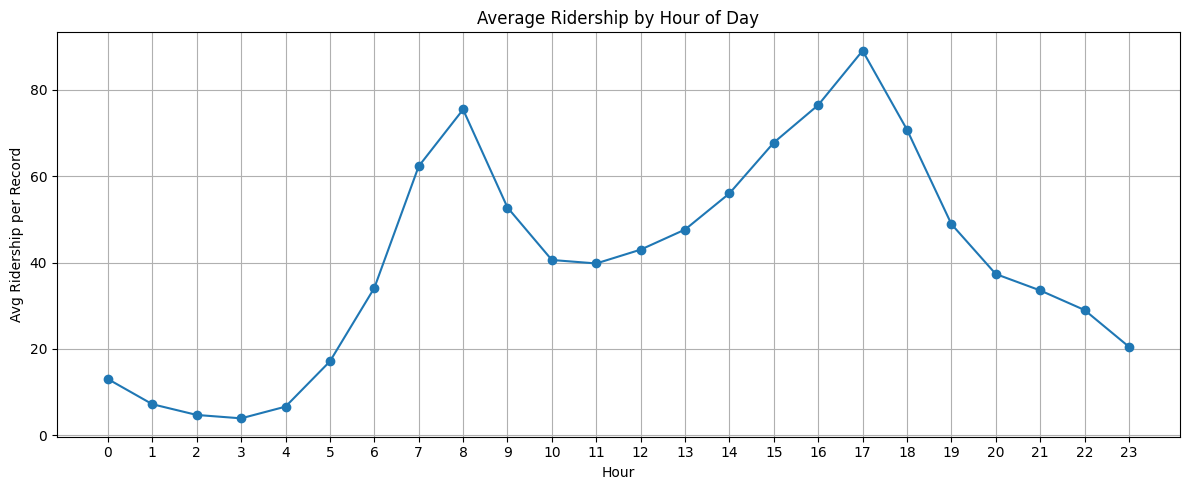

In [33]:
hourly = get_ridership_by_hour()

plt.figure(figsize=(12, 5))
plt.plot(hourly['hour_of_day'], hourly['avg_ridership'], marker='o')
plt.title('Average Ridership by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Ridership per Record')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

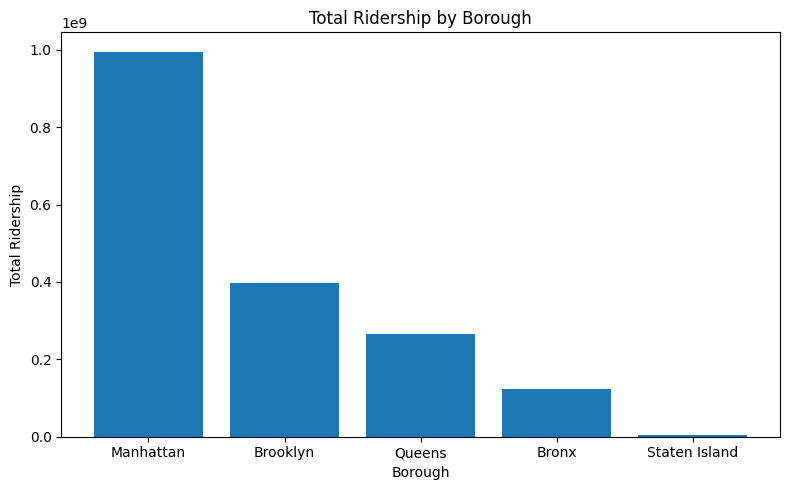

In [34]:
borough = get_ridership_by_borough()

plt.figure(figsize=(8, 5))
plt.bar(borough['borough'], borough['total_ridership'])
plt.title('Total Ridership by Borough')
plt.xlabel('Borough')
plt.ylabel('Total Ridership')
plt.tight_layout()
plt.show()

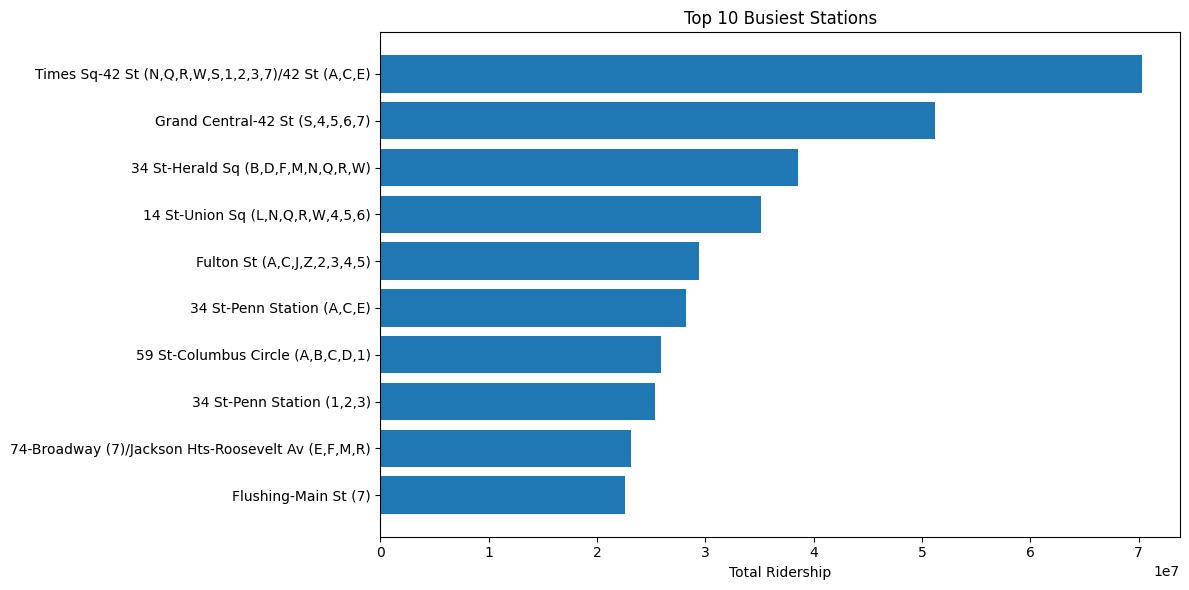

In [35]:
stations = get_busiest_stations(limit=10)

plt.figure(figsize=(12, 6))
plt.barh(stations['station_complex'], stations['total_ridership'])
plt.title('Top 10 Busiest Stations')
plt.xlabel('Total Ridership')
plt.gca().invert_yaxis()  # busiest at top
plt.tight_layout()
plt.show()

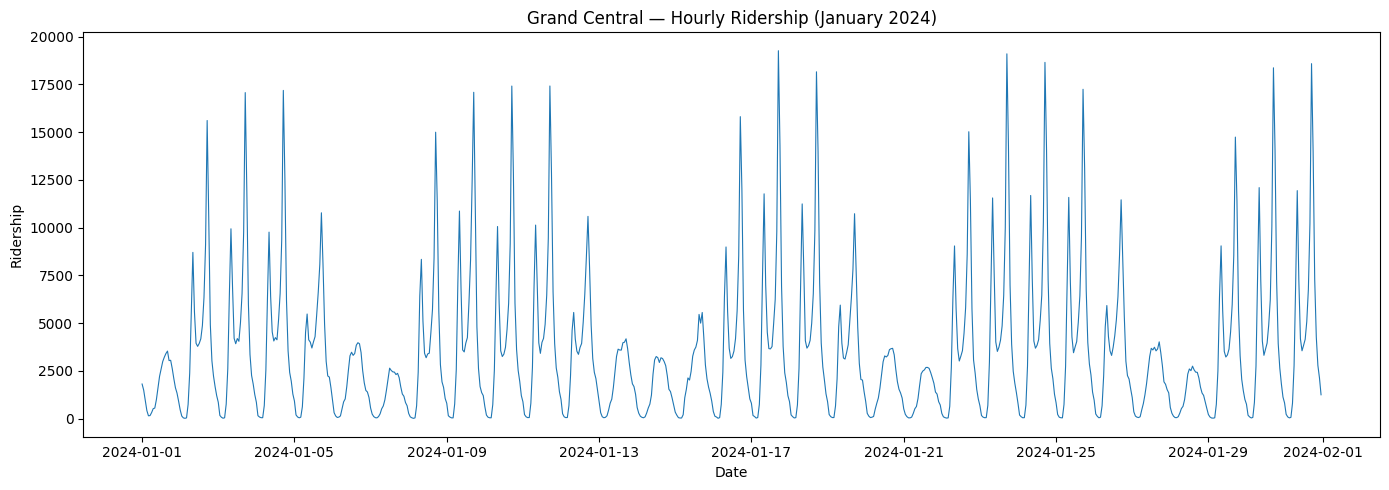

In [36]:
gc = get_hourly_ridership(
    station="Grand Central-42 St (S,4,5,6,7)",
    start="2024-01-01",
    end="2024-02-01"
)

plt.figure(figsize=(14, 5))
plt.plot(gc['transit_timestamp'], gc['ridership'], linewidth=0.8)
plt.title('Grand Central — Hourly Ridership (January 2024)')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.tight_layout()
plt.show()

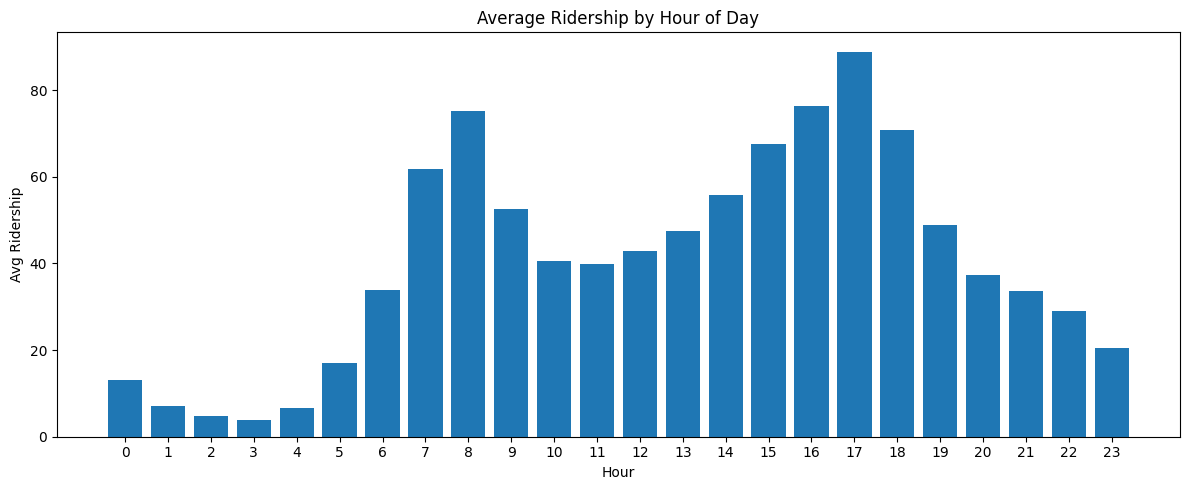

In [37]:
hourly = get_ridership_by_hour()

# We'll add day of week breakdown to query.py soon, but for now:
plt.figure(figsize=(12, 5))
plt.bar(hourly['hour_of_day'], hourly['avg_ridership'])
plt.title('Average Ridership by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Avg Ridership')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [ ]:
from src.query import get_ridership_by_day_of_week

dow = get_ridership_by_day_of_week()

days = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
colors = ['lightblue', 'steelblue', 'steelblue', 'steelblue', 'steelblue', 'mediumpurple', 'lightblue']

plt.figure(figsize=(14, 6))
for i, day in enumerate(days):
    day_data = dow[dow['day_name'] == day]
    plt.plot(day_data['hour_of_day'], day_data['avg_ridership'], 
             label=day, color=colors[i], 
             linewidth=2 if day in ['Friday', 'Saturday', 'Sunday'] else 1,
             linestyle='--' if day == 'Friday' else '-')

plt.title('Average Ridership by Hour — Day of Week Comparison')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Ridership')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()